In [1]:
from instancepipeline import get_data_loaders

Train samples: 979487
Validation samples: 96993
Test samples: 82769
Train batches: 7653
Val batches: 758
Test batches: 647


In [2]:
train_loader,val_loader,test_loader = get_data_loaders()


In [3]:
import torch
import torch.nn

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [5]:
TARGET_MEAN = 2.28802128052746


In [6]:
import pandas as pd

In [7]:
all_targets = []

for waveforms, magnitudes in train_loader:

    magnitudes = magnitudes.to(device)

    

    all_targets.append(
        magnitudes.cpu()
    )


all_targets = torch.cat(
    all_targets
).numpy()


targets = pd.DataFrame({
    "magnitude": all_targets
})


targets.head(5)

,magnitude
0,3.0
1,2.2
2,2.8
3,3.1
4,2.1


In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt

MIN_MAGNITUDE = 0.0
MAX_MAGNITUDE = 6.6
BIN_WIDTH = 0.1


bin_edges = np.arange(
    MIN_MAGNITUDE,
    MAX_MAGNITUDE + BIN_WIDTH,
    BIN_WIDTH
)

counts, _ = np.histogram(targets["magnitude"].values,bins=bin_edges)

epsilon = 1.0

smoothed_counts = counts.astype(np.float64) + epsilon

prior_probs = smoothed_counts / smoothed_counts.sum()


bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

print("Number of bins:", len(prior_probs))
print("Sum:", prior_probs.sum())
print("Min probability:", prior_probs.min())
print("Max probability:", prior_probs.max())

Number of bins: 66
Sum: 1.0
Min probability: 1.0208738067261293e-06
Max probability: 0.21031429641887678


In [9]:
len(prior_probs)

66

In [ ]:
prior_probs = torch.tensor(
    prior_probs,
    dtype=torch.float32
)

In [11]:
print(prior_probs.shape)
print(prior_probs.sum())

torch.Size([66])
tensor(1.)


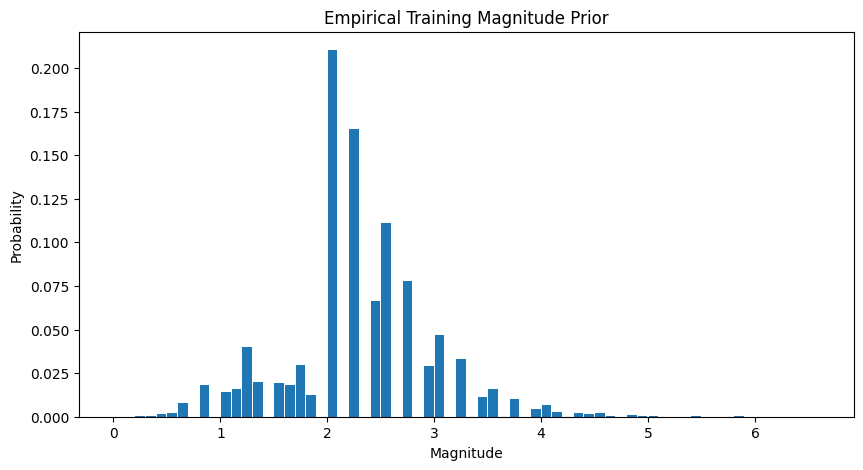

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    bin_centers,
    prior_probs.numpy(),
    width=0.09
)

plt.xlabel("Magnitude")
plt.ylabel("Probability")
plt.title("Empirical Training Magnitude Prior")

plt.show()

In [13]:
import pandas as pd

prior_df = pd.DataFrame({
    "magnitude": bin_centers,
    "count": counts,
    "probability": prior_probs.numpy()
})

print(prior_df)

    magnitude  count  probability
0        0.05     24     0.000026
1        0.15     71     0.000074
2        0.25    228     0.000234
3        0.35    467     0.000478
4        0.45   1363     0.001392
..        ...    ...          ...
61       6.15      0     0.000001
62       6.25      0     0.000001
63       6.35      0     0.000001
64       6.45      0     0.000001
65       6.55     75     0.000078

[66 rows x 3 columns]


In [15]:
prior_df.to_csv("prior_df.csv")

In [ ]:
from scipy.ndimage import gaussian_filter1d

smoothed_counts = gaussian_filter1d(
    counts.astype(float),
    sigma=1.0
)


smoothed_counts += 1.0

smoothed_prior = (
    smoothed_counts /
    smoothed_counts.sum()
)

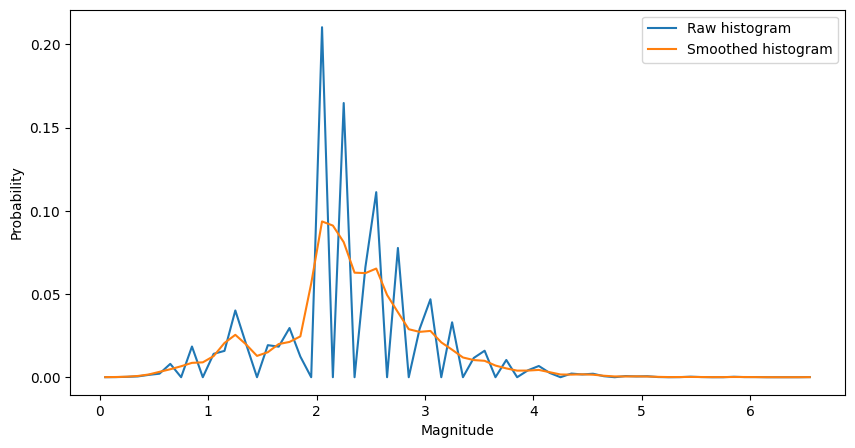

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    bin_centers,
    prior_probs,
    label="Raw histogram"
)

plt.plot(
    bin_centers,
    smoothed_prior,
    label="Smoothed histogram"
)

plt.xlabel("Magnitude")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [29]:
torch.save(
    smoothed_prior,
    "data/smoothed_magnitude_prior.pt"
)

In [19]:
import numpy as np
import matplotlib.pyplot as plt

mags = targets["magnitude"].dropna().to_numpy()

MIN_MAGNITUDE = 0.0
MAX_MAGNITUDE = 6.6
BIN_WIDTH = 0.1
PSEUDOCOUNT = 1.0

bin_edges = np.arange(
    MIN_MAGNITUDE,
    MAX_MAGNITUDE + BIN_WIDTH,
    BIN_WIDTH
)

bin_centers = (
    bin_edges[:-1] + bin_edges[1:]
) / 2

counts, _ = np.histogram(
    mags,
    bins=bin_edges
)

def normalize(values):
    values = np.asarray(values, dtype=float)
    values = values + PSEUDOCOUNT
    return values / values.sum()

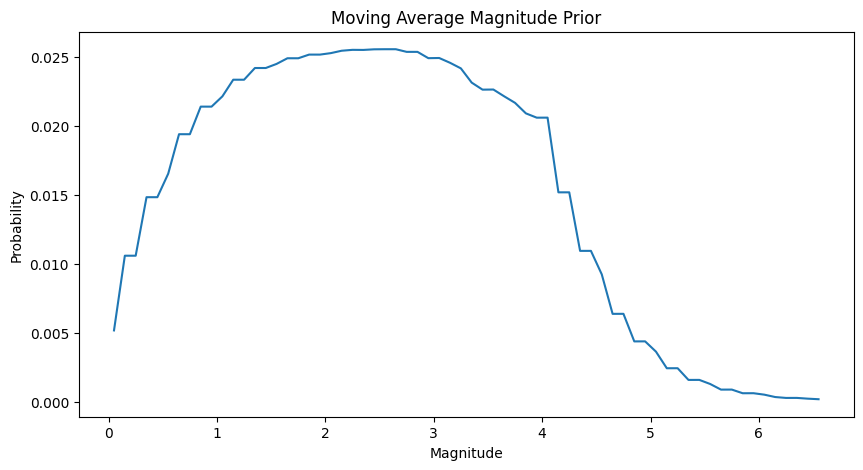

In [23]:
from scipy.ndimage import uniform_filter1d

WINDOW_SIZE = 40
moving_counts = uniform_filter1d(
    counts.astype(float),
    size=WINDOW_SIZE,
    mode="nearest"
)

moving_prior = normalize(moving_counts)

plt.figure(figsize=(10, 5))
plt.plot(bin_centers, moving_prior)

plt.xlabel("Magnitude")
plt.ylabel("Probability")
plt.title("Moving Average Magnitude Prior")

plt.show()

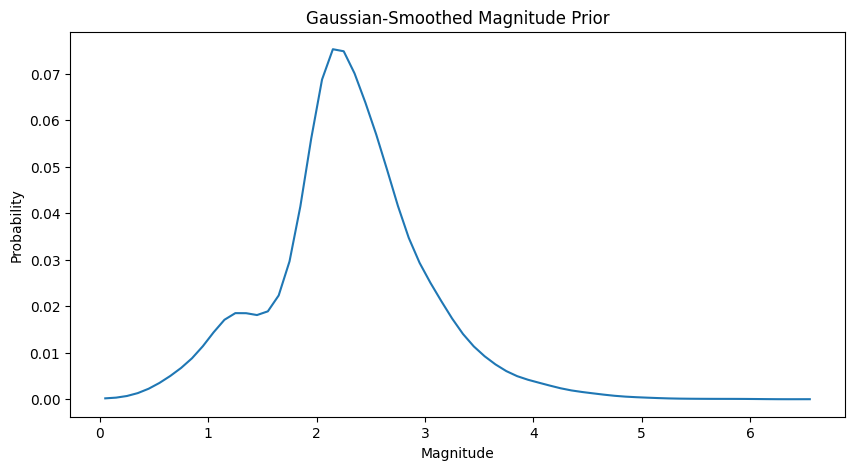

In [25]:
from scipy.ndimage import gaussian_filter1d

SIGMA = 2

gaussian_counts = gaussian_filter1d(
    counts.astype(float),
    sigma=SIGMA
)

gaussian_prior = normalize(
    gaussian_counts
)

plt.figure(figsize=(10, 5))
plt.plot(bin_centers, gaussian_prior)

plt.xlabel("Magnitude")
plt.ylabel("Probability")
plt.title("Gaussian-Smoothed Magnitude Prior")

plt.show()

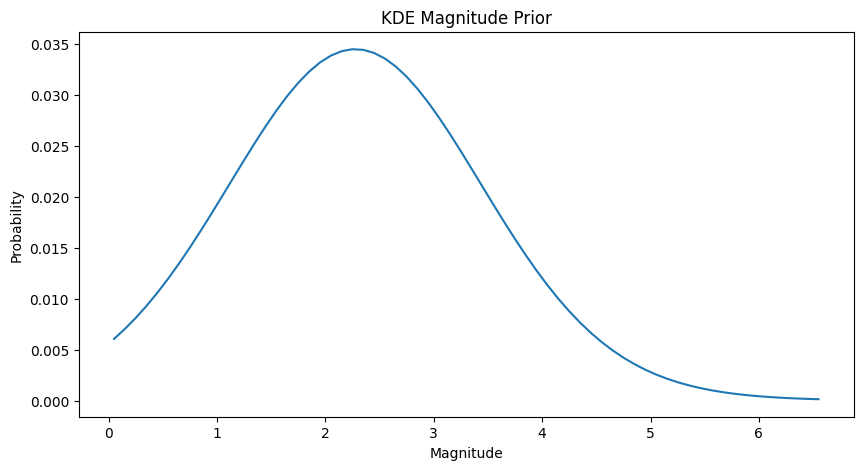

In [27]:
from sklearn.neighbors import KernelDensity

BANDWIDTH = 1

kde = KernelDensity(
    kernel="gaussian",
    bandwidth=BANDWIDTH
)

kde.fit(
    mags.reshape(-1, 1)
)

log_density = kde.score_samples(
    bin_centers.reshape(-1, 1)
)

kde_density = np.exp(log_density)

kde_prior = (
    kde_density /
    kde_density.sum()
)

plt.figure(figsize=(10, 5))
plt.plot(bin_centers, kde_prior)

plt.xlabel("Magnitude")
plt.ylabel("Probability")
plt.title("KDE Magnitude Prior")

plt.show()

Mean: 2.2880218
Std: 0.68812394


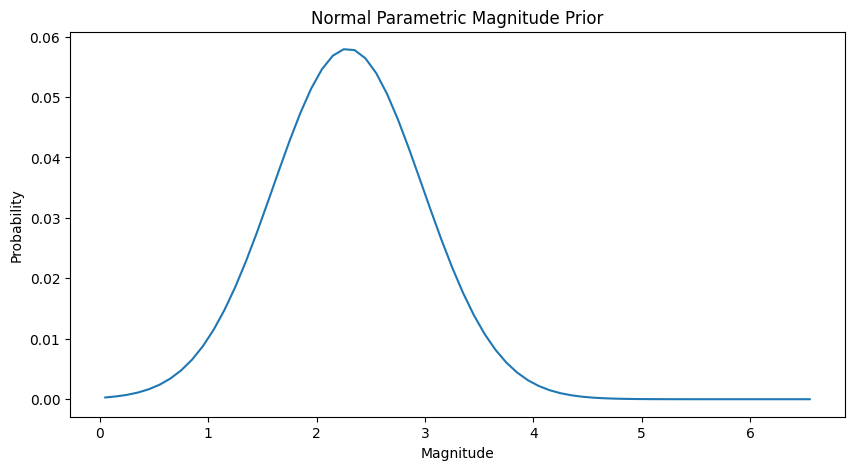

In [28]:
from scipy.stats import norm

mu, std = norm.fit(mags)

parametric_density = norm.pdf(
    bin_centers,
    loc=mu,
    scale=std
)

parametric_prior = (
    parametric_density /
    parametric_density.sum()
)

print("Mean:", mu)
print("Std:", std)

plt.figure(figsize=(10, 5))
plt.plot(bin_centers, parametric_prior)

plt.xlabel("Magnitude")
plt.ylabel("Probability")
plt.title("Normal Parametric Magnitude Prior")

plt.show()